**Predict Customer Churn using dataset from Kaggle** 

In [42]:
# Importing the required packages
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier as dtc # tree algorithm
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Churn_df = pd.read_csv('Churn_Modelling.csv')


**Get info on columns in dataset** 

In [43]:
Churn_df.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


**Find shape of dataset**

In [44]:
Churn_df.shape

(10000, 13)

**Display first 5 rows of dataset**

In [45]:
Churn_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


**Display last 5 rows**

In [46]:
Churn_df.tail()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


**Find unique rows in Geography for converting to categorical values later**

In [47]:
Churn_df.Geography.unique()

<ArrowStringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

**encode Gender rows**

In [48]:
Churn_df["Gender"] = Churn_df["Gender"].map({"Female": 0, "Male": 1})

**Count of customers exited and stayed**

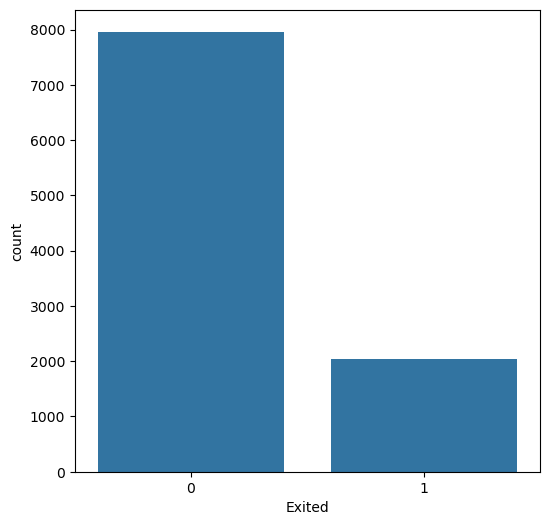

In [49]:
plt.figure(figsize=(6,6))
sns.countplot(x=Churn_df['Exited'])
plt.show()

**Display Column names # of nulls and datatype** 

In [50]:
Churn_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  str    
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  str    
 4   Gender           10000 non-null  int64  
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(2)
memory usage: 1.1 MB


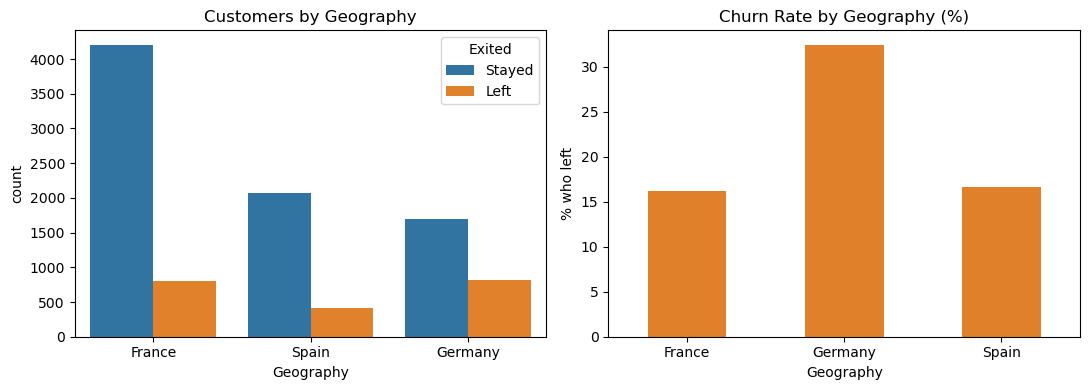

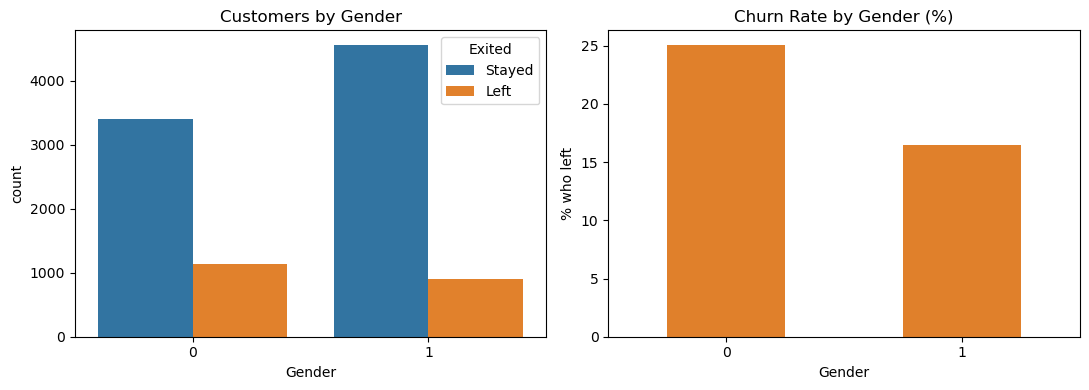

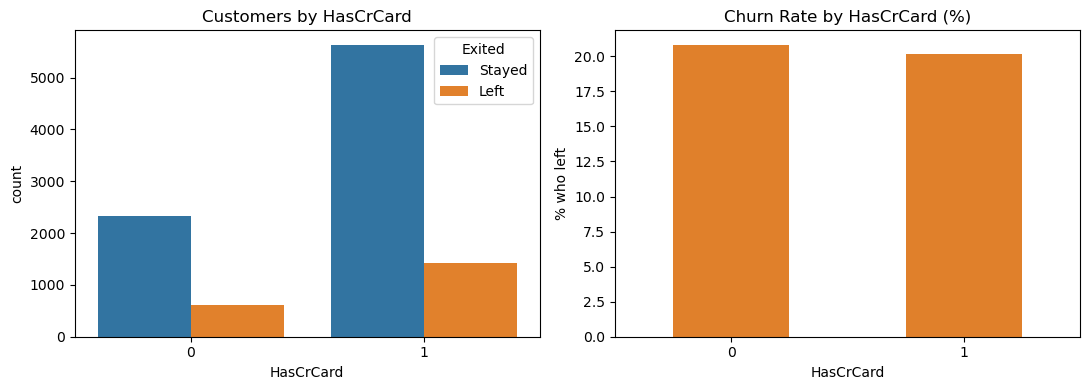

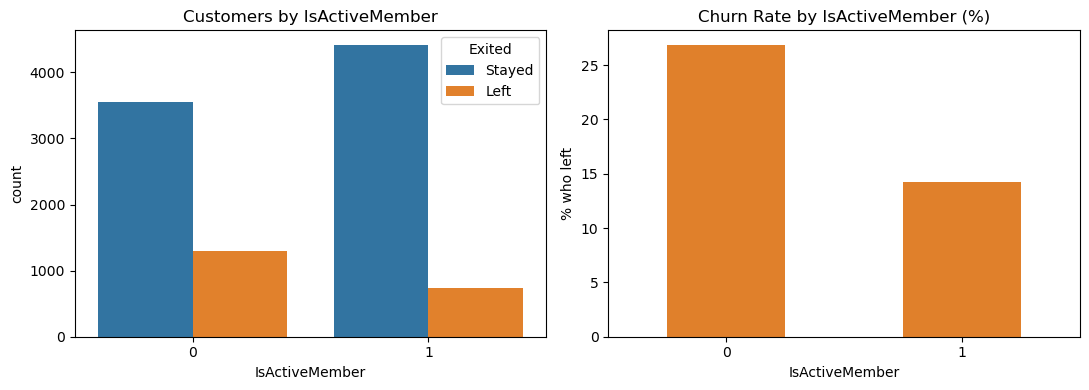

In [51]:
cat_cols = ["Geography", "Gender", "HasCrCard", "IsActiveMember"]

for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sns.countplot(data=Churn_df, x=col, hue="Exited", ax=axes[0])
    axes[0].set_title(f"Customers by {col}")
    axes[0].legend(title="Exited", labels=["Stayed", "Left"])

    (Churn_df.groupby(col)["Exited"].mean() * 100).plot(kind="bar", color="#E0802B", ax=axes[1])
    axes[1].set_title(f"Churn Rate by {col} (%)")
    axes[1].set_ylabel("% who left")
    axes[1].tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.show()

**Create Box plots of numeric variables in dataset compared to exited**

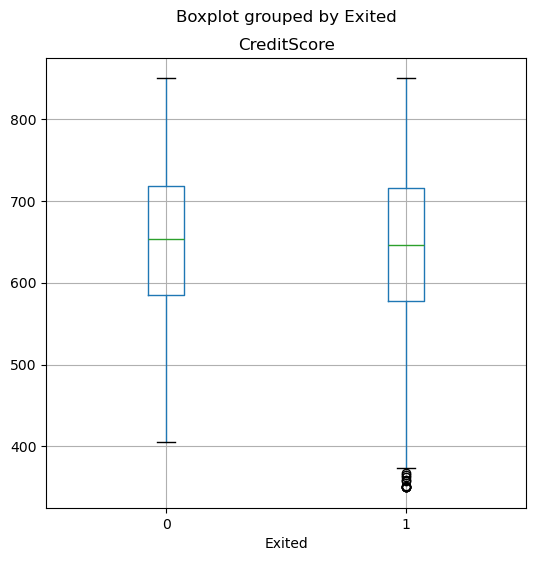

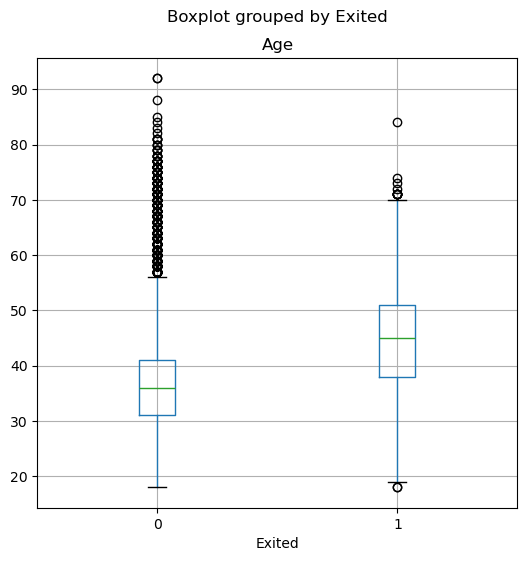

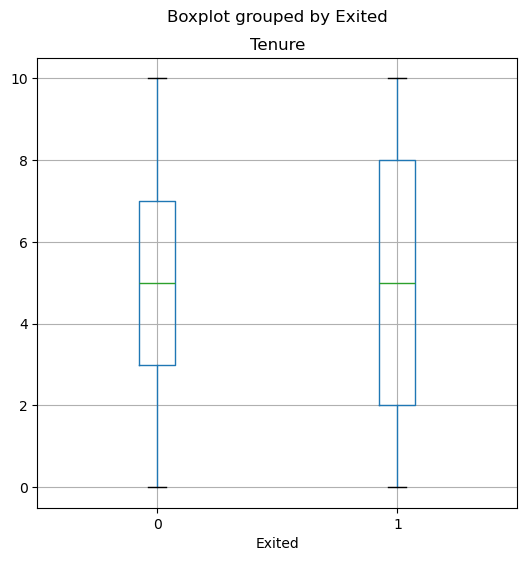

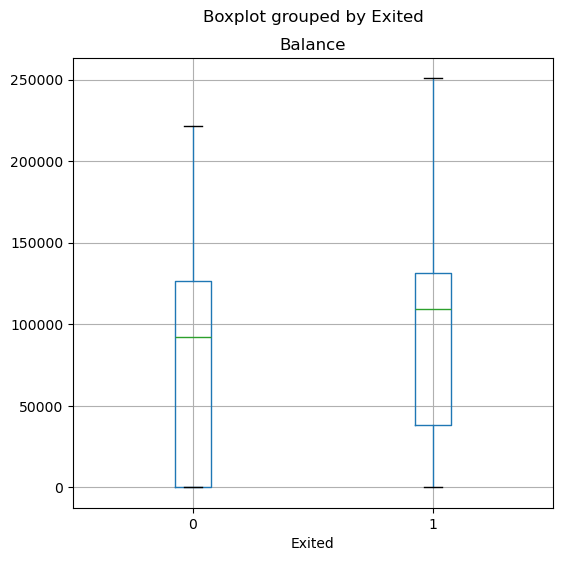

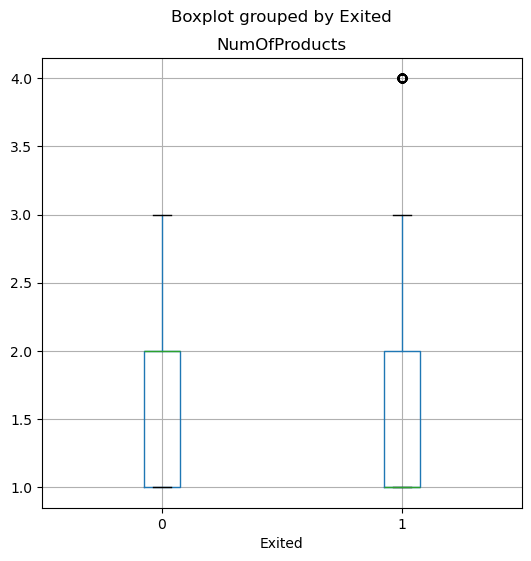

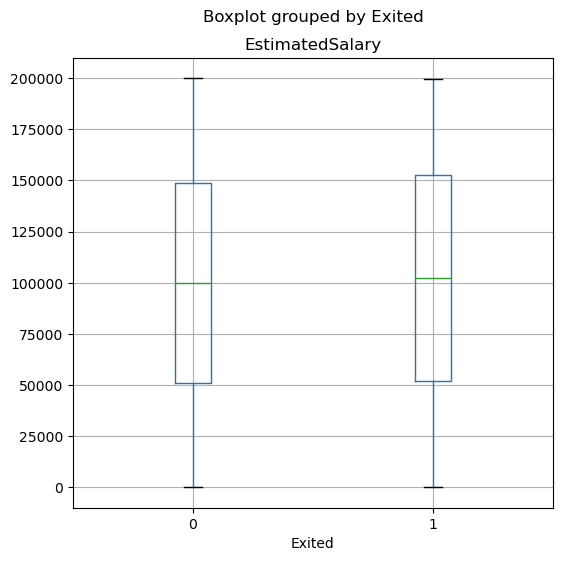

In [52]:
from matplotlib import pyplot as plt
%matplotlib inline

features = ['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary']
for col in features:
    Churn_df.boxplot(column=col, by='Exited', figsize=(6,6))
    plt.title(col)
plt.show()

**See Categorical Variables with respect to Exited. Code copied from Analytics Vidyha**

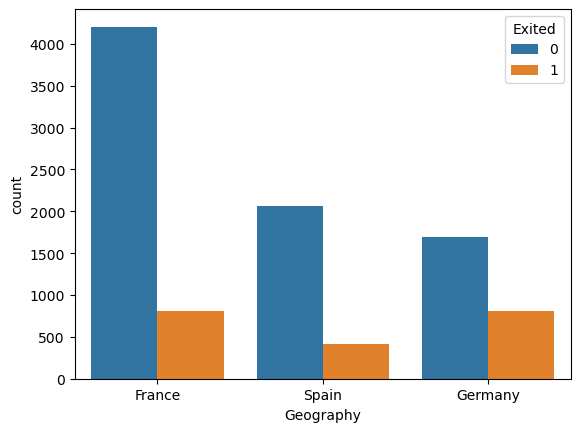

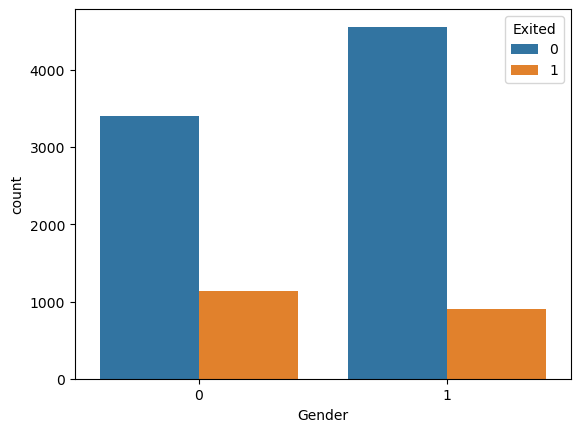

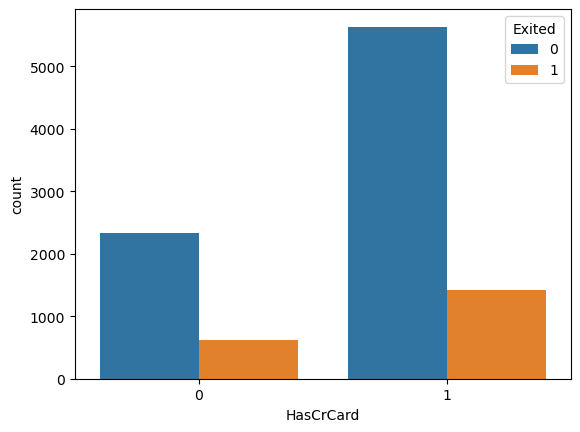

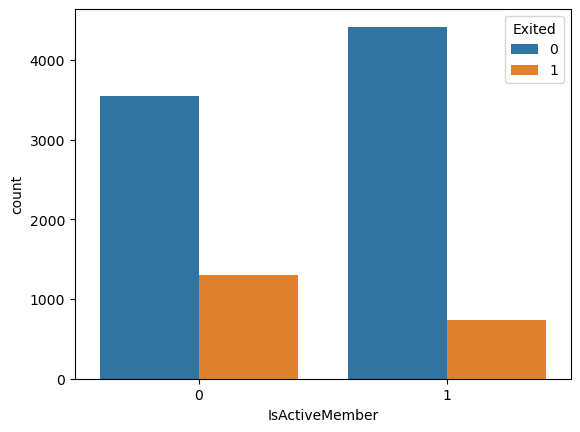

In [53]:
for i, predictor in enumerate(Churn_df.drop(columns = ['Exited','CustomerId','Surname','EstimatedSalary','CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary'])):
    plt.figure(i)
    sns.countplot(data=Churn_df, x= predictor, hue = 'Exited')

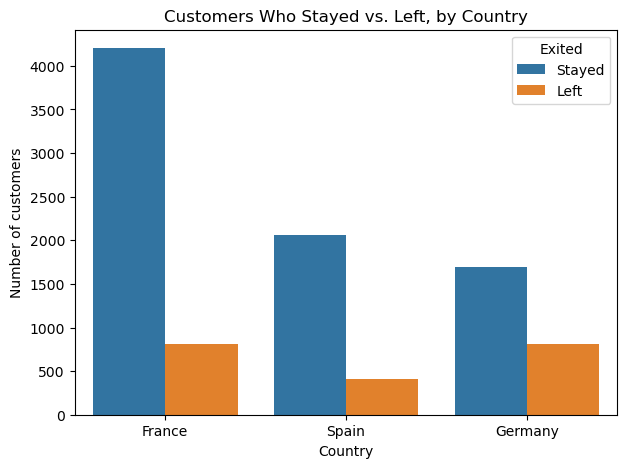

In [54]:
plt.figure(figsize=(7,5))
sns.countplot(data=Churn_df, x="Geography", hue="Exited")
plt.title("Customers Who Stayed vs. Left, by Country")
plt.xlabel("Country"); plt.ylabel("Number of customers")
plt.legend(title="Exited", labels=["Stayed", "Left"])
plt.show()

In [55]:
Churn_df

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,Obijiaku,771,France,1,39,5,0.00,2,1,0,96270.64,0
9996,15569892,Johnstone,516,France,1,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,Liu,709,France,0,36,7,0.00,1,0,1,42085.58,1
9998,15682355,Sabbatini,772,Germany,1,42,3,75075.31,2,1,0,92888.52,1


**Drop row number, surname ,georgrphy and customer id which do not have anything to do with churn**

In [56]:
Churn_df = Churn_df.drop(columns=['Surname', 'CustomerId','Geography'], errors='ignore')
Churn_df.head()


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,42,2,0.00,1,1,1,101348.88,1
1,608,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,39,1,0.00,2,0,0,93826.63,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0


**Correlation values**

In [57]:

corrM = Churn_df.corr()
corrM = corrM.sort_values(by ='Exited',ascending=False)
print(corrM)

                 CreditScore    Gender       Age    Tenure   Balance  \
Exited             -0.027094 -0.106512  0.285323 -0.014001  0.118533   
Age                -0.003965 -0.027544  1.000000 -0.009997  0.028308   
Balance             0.006268  0.012087  0.028308 -0.012254  1.000000   
EstimatedSalary    -0.001384 -0.008112 -0.007201  0.007784  0.012797   
HasCrCard          -0.005458  0.005766 -0.011721  0.022583 -0.014858   
Tenure              0.000842  0.014733 -0.009997  1.000000 -0.012254   
CreditScore         1.000000 -0.002857 -0.003965  0.000842  0.006268   
NumOfProducts       0.012238 -0.021859 -0.030680  0.013444 -0.304180   
Gender             -0.002857  1.000000 -0.027544  0.014733  0.012087   
IsActiveMember      0.025651  0.022544  0.085472 -0.028362 -0.010084   

                 NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  \
Exited               -0.047820  -0.007138       -0.156128         0.012097   
Age                  -0.030680  -0.011721        0.

**Create Correlation heatmap**

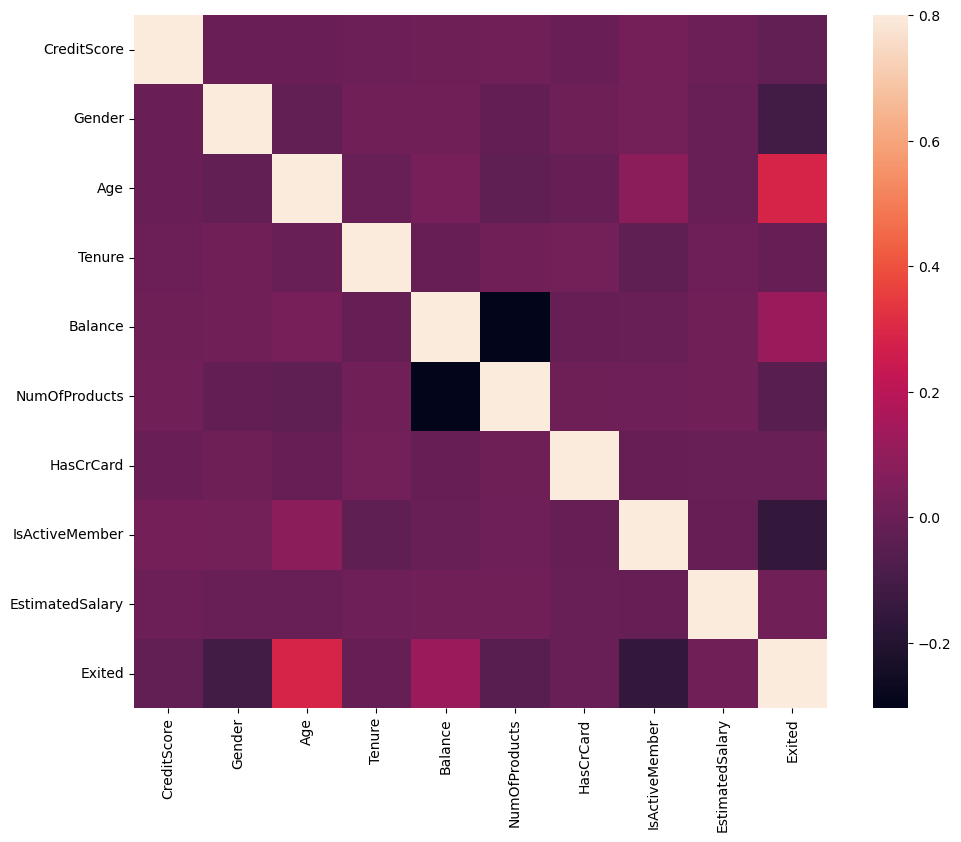

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

corrmat = Churn_df.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat,vmax=.8,  square=True);

**Create boxplots of Exited by Age, IsActiveMemeber,Balance and Credit Score**

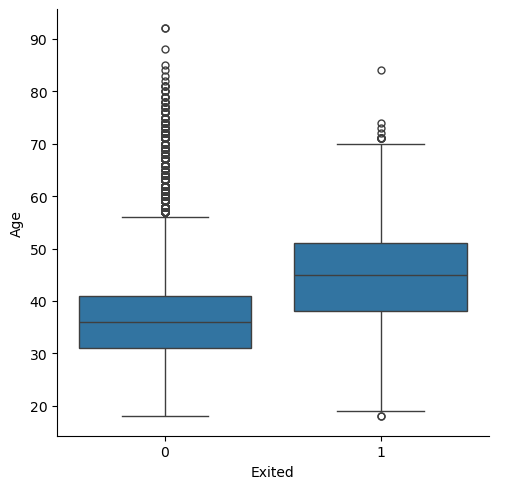

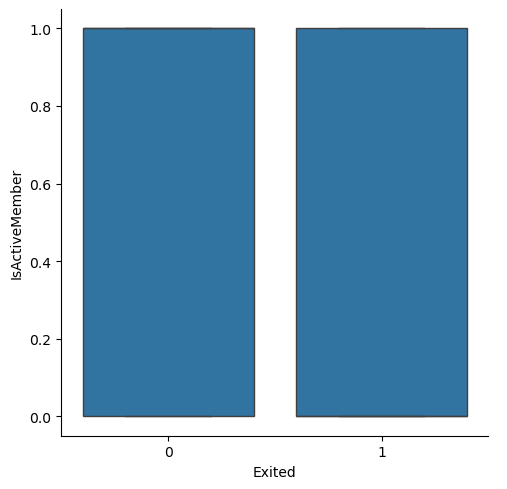

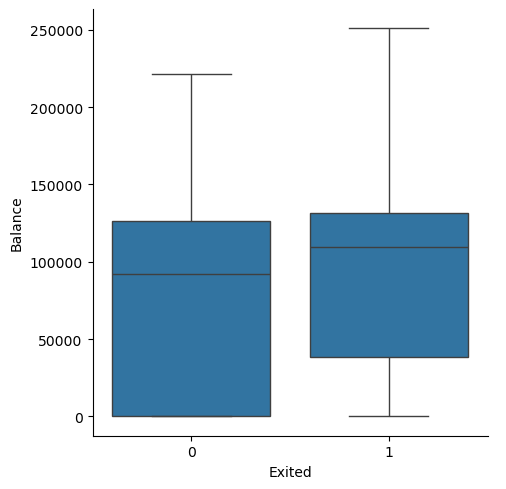

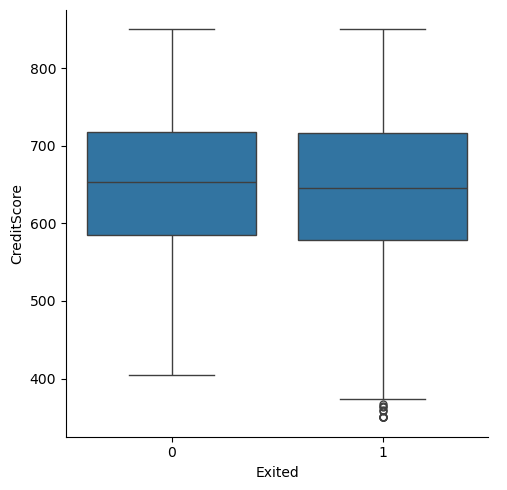

In [59]:
sns.catplot(x="Exited", y="Age",  kind="box",data=Churn_df)
sns.catplot(x="Exited", y="IsActiveMember",  kind="box",data=Churn_df)
sns.catplot(x="Exited", y="Balance",  kind="box",data=Churn_df);
sns.catplot(x="Exited", y="CreditScore",  kind="box",data=Churn_df);

**Show skewness**

In [60]:
print("Skewness: %f" % Churn_df['Balance'].skew())

Skewness: -0.141109


**Ordinal Encode Exited, Geography and Gender**

In [61]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
enc.fit(Churn_df[['Exited']])
Churn_df[['Exited']] = enc.transform(Churn_df[['Exited']])

In [62]:
if "Geography" in Churn_df.columns:
    Churn_df = pd.get_dummies(Churn_df, columns=["Geography"], drop_first=True, dtype=int)
print(Churn_df.columns.tolist())

['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [63]:
Churn_df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,42,2,0.00,1,1,1,101348.88,1.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1.0
3,699,0,39,1,0.00,2,0,0,93826.63,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0.0


In [64]:
feature_cols  = ['CreditScore',   'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
target = Churn_df['Exited']
X = Churn_df[feature_cols]
y = target

In [65]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)

**Model using a decision tree**

In [66]:
from sklearn import tree
model = dtc(criterion = 'entropy', max_depth = 4)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

**Determine Accuracy of model**

In [67]:
accuracy_score(y_test, y_pred)

0.8572

**Text representation of Decision Tree**

In [68]:
text_representation = tree.export_text(model)
print(text_representation)


|--- feature_1 <= 41.50
|   |--- feature_4 <= 2.50
|   |   |--- feature_4 <= 1.50
|   |   |   |--- feature_1 <= 34.50
|   |   |   |   |--- class: 0.0
|   |   |   |--- feature_1 >  34.50
|   |   |   |   |--- class: 0.0
|   |   |--- feature_4 >  1.50
|   |   |   |--- feature_3 <= 1884.34
|   |   |   |   |--- class: 0.0
|   |   |   |--- feature_3 >  1884.34
|   |   |   |   |--- class: 0.0
|   |--- feature_4 >  2.50
|   |   |--- feature_3 <= 23194.08
|   |   |   |--- feature_7 <= 168592.80
|   |   |   |   |--- class: 0.0
|   |   |   |--- feature_7 >  168592.80
|   |   |   |   |--- class: 1.0
|   |   |--- feature_3 >  23194.08
|   |   |   |--- feature_0 <= 682.00
|   |   |   |   |--- class: 1.0
|   |   |   |--- feature_0 >  682.00
|   |   |   |   |--- class: 1.0
|--- feature_1 >  41.50
|   |--- feature_4 <= 2.50
|   |   |--- feature_4 <= 1.50
|   |   |   |--- feature_6 <= 0.50
|   |   |   |   |--- class: 1.0
|   |   |   |--- feature_6 >  0.50
|   |   |   |   |--- class: 0.0
|   |   |--- fea

**Create Confusion Matrix**

In [69]:
pd.crosstab(y_test, y_pred, rownames=['True'], colnames=['Predicted'], margins=True)

Predicted,0.0,1.0,All
True,,,
0.0,1907,84,1991
1.0,273,236,509
All,2180,320,2500


**Metrics Classification of model**

In [70]:
import sklearn.metrics as metrics
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.87      0.96      0.91      1991
         1.0       0.74      0.46      0.57       509

    accuracy                           0.86      2500
   macro avg       0.81      0.71      0.74      2500
weighted avg       0.85      0.86      0.84      2500



**Calculate ROC and create roc curve**

In [71]:
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred)

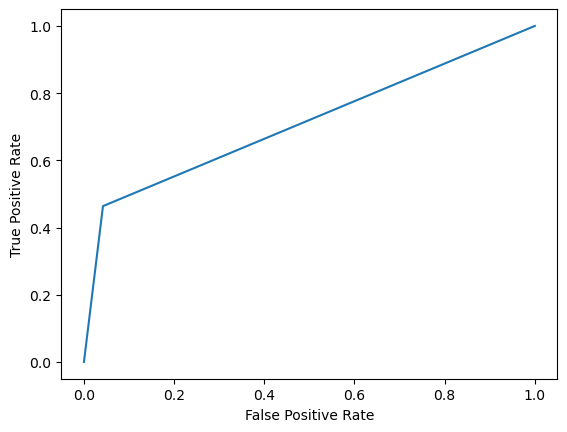

In [72]:
#create ROC curve
plt.plot(fpr,tpr)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

**Run Support Vector to see if it is more accurate than Decision tree** 

In [73]:
from sklearn.svm import SVC
model = SVC( )
model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [74]:
model.score(X_test, y_test)
kf=KFold(n_splits=5)
score=cross_val_score(model,X_train,y_train,cv=kf)
print("Cross Validation Scores are {}".format(score))
print("Average Cross Validation score :{}".format(score.mean()))

Cross Validation Scores are [0.78733333 0.79533333 0.81266667 0.78933333 0.79666667]
Average Cross Validation score :0.7962666666666667


**Run logistic regression with cross validation to see if it is more accurate than Decision tree** 

**Run Random Forest to see if it is more accurate than Decision tree** 

In [75]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=170)
clf.fit(X_train,y_train);

**Random Forest appears to be the best at 86.36 vs 85.72 for decision tree**

In [76]:
y_pred=clf.predict(X_test)
Accuracy = metrics.accuracy_score(y_test, y_pred)
print('Accuracy: %.2f' % (Accuracy*100))


Accuracy: 86.08


**Run Classification report for Random Forest**

In [77]:
import sklearn.metrics as metrics
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.88      0.96      0.92      1991
         1.0       0.75      0.47      0.58       509

    accuracy                           0.86      2500
   macro avg       0.81      0.72      0.75      2500
weighted avg       0.85      0.86      0.85      2500



**use boosting ensemble**

In [78]:
import pandas
from sklearn import model_selection
from sklearn.ensemble import GradientBoostingClassifier
seed = 7
num_trees = 100
kfold = model_selection.KFold(n_splits=10, random_state=None)
model = GradientBoostingClassifier(n_estimators=num_trees, random_state=seed)
results = model_selection.cross_val_score(model, X_test, y_test, cv=kfold)
print(results.mean())

0.8583999999999999


### **Mean .8583 so it is near the top but not as good as Random Forest**

In [79]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=10)),
    "SVM": make_pipeline(StandardScaler(), SVC(probability=True)),
    "Decision Tree": DecisionTreeClassifier(criterion="entropy", max_depth=4),
    "Random Forest": RandomForestClassifier(n_estimators=170, random_state=0),
    "Gradient Boosting": GradientBoostingClassifier(random_state=7),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
results = {name: cross_val_score(m, X_train, y_train, cv=cv, scoring="roc_auc").mean()
           for name, m in models.items()}
pd.Series(results).sort_values(ascending=False).round(3)

Gradient Boosting      0.843
Random Forest          0.822
Decision Tree          0.816
SVM                    0.794
Logistic Regression    0.739
dtype: float64

Gradient Boosting test AUC: 0.859
              precision    recall  f1-score   support

         0.0       0.88      0.96      0.92      1991
         1.0       0.76      0.47      0.58       509

    accuracy                           0.86      2500
   macro avg       0.82      0.72      0.75      2500
weighted avg       0.85      0.86      0.85      2500



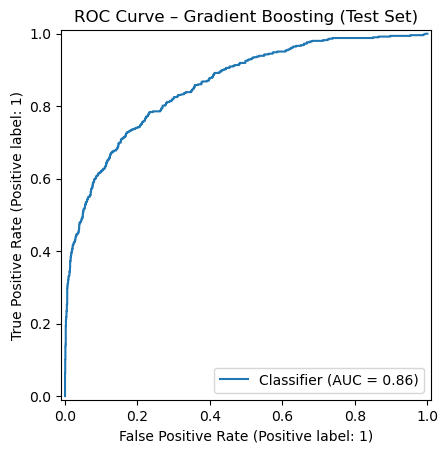

In [80]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay, classification_report

best = GradientBoostingClassifier(random_state=7)
best.fit(X_train, y_train)

probs = best.predict_proba(X_test)[:, 1]
print("Gradient Boosting test AUC:", round(roc_auc_score(y_test, probs), 3))
print(classification_report(y_test, best.predict(X_test)))

RocCurveDisplay.from_predictions(y_test, probs)
plt.title("ROC Curve – Gradient Boosting (Test Set)")
plt.show()

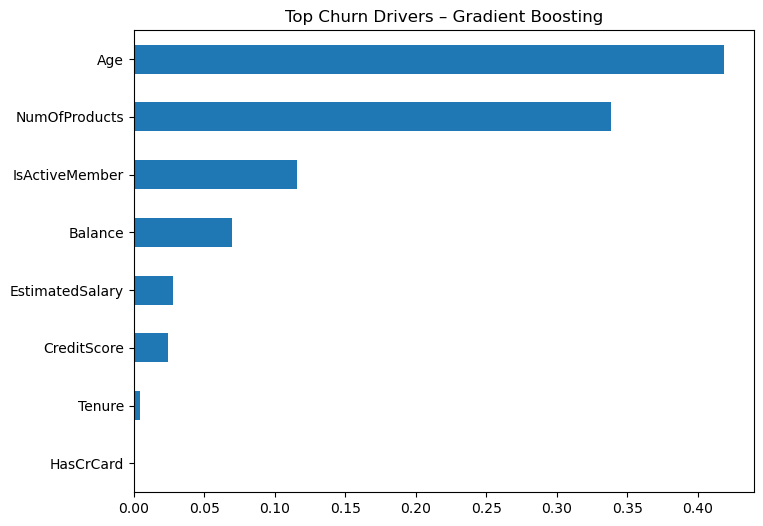

In [81]:
pd.Series(best.feature_importances_, index=feature_cols).sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Top Churn Drivers – Gradient Boosting")
plt.show()

In [82]:
lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
lr.fit(X_train, y_train)
print(lr.named_steps["logisticregression"].n_iter_)

[6]
